In [1]:
# locate the root folder
CODE_DIR = '/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive/'

import os
os.chdir(f'{CODE_DIR}')

notebook_path = os.getcwd()
print('Current working directory is:', '\n', notebook_path) 

# import time
# import math
# from typing import Tuple, Optional, List

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torch.nn.functional as F
from models.stylegan2_mlp import MappingNetwork, MappingNetwork_cs, MappingNetwork_cs_sparsity, EqualizedLinear
import matplotlib.pyplot as plt

Current working directory is: 
 /home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/pSp_encoder_constructive


In [2]:
def L1_lasso_output_regularization(output, reg_type='row'):
    if reg_type == 'row':
        return torch.sum(torch.abs(output).sum(dim=2))
    elif reg_type == 'column':
        return torch.sum(torch.abs(output).sum(dim=1))
    elif reg_type == 'element':
        return torch.sum(torch.abs(output))
    else:
        raise ValueError(f"Invalid regularization type: '{reg_type}'.")

def L1_lasso_weight_regularization(model, network='net_s', reg_type='all'):
    """
    Apply L1 regularization on the specified layers of either `net_s` or `net_c` in the model.

    Args:
        model (MappingNetwork_cs_sparsity): The model with the network to regularize.
        network (str): The network to apply Lasso regularization ('net_s' or 'net_c').
        reg_type (str): Type of weight regularization ('all' or 'last').
            - 'all': Applies Lasso to all EqualizedLinear layers in the specified network.
            - 'last': Applies Lasso only to the last EqualizedLinear layer in the specified network.

    Returns:
        torch.Tensor: Computed L1 regularization penalty for the selected layers.
    """
    lasso_weight_penalty = 0.0
    
    # Select the target network based on the network argument
    target_network = getattr(model, network, None)
    if target_network is None:
        raise ValueError(f"Invalid network '{network}'. Use 'net_s' or 'net_c'.")

    # Get layers of the selected network
    layers = list(target_network.children())

    if reg_type == 'all':
        # Apply Lasso to all EqualizedLinear layers in the target network
        for layer in layers:
            if isinstance(layer[0], EqualizedLinear):
                lasso_weight_penalty += torch.sum(torch.abs(layer[0].weight.weight))  # Access raw weight tensor
    elif reg_type == 'last':
        # Apply Lasso only to the last EqualizedLinear layer in the target network
        last_layer = layers[-1][0]
        if isinstance(last_layer, EqualizedLinear):
            lasso_weight_penalty += torch.sum(torch.abs(last_layer.weight.weight))  # Access raw weight tensor
    else:
        raise ValueError(f"Invalid reg_type '{reg_type}'. Use 'all' or 'last'.")

    return lasso_weight_penalty


def calculate_latent_loss(latent_bg_s, latent_t_s, latent_bg, latent_t, latent_bg_target, latent_t_target, 
                          lasso_output_lambda=0.01, lasso_weight_lambda=0.01, model=None, 
                          lasso_output_type='row', lasso_weight_type='all', network='net_s'):
    """
    Calculate total loss, including L1 regularization for output and weights.

    Args:
        latent_bg_s: Background latent tensor.
        latent_t_s: Target latent tensor.
        latent_bg: Background tensor.
        latent_t: Target tensor.
        latent_bg_target: Target tensor for background.
        latent_t_target: Target tensor for output.
        lasso_output_lambda: Weight for output L1 regularization.
        lasso_weight_lambda: Weight for weight L1 regularization.
        model: The model on which to apply regularization.
        lasso_output_type: Type of L1 regularization for output ('row', 'column', 'element').
        lasso_weight_type: Type of L1 regularization for weights ('all', 'last').
        network: Specifies 'net_s' or 'net_c' for weight regularization.

    Returns:
        total_loss: Computed total loss.
        loss_dict: Dictionary with individual loss components.
    """
    loss_silent_bg = F.mse_loss(latent_bg_s, torch.zeros_like(latent_bg_s))
    loss_distance_bg = F.mse_loss(latent_bg, latent_bg_target)
    loss_distance_t = F.mse_loss(latent_t, latent_t_target)
    
    lasso_output_loss = lasso_output_lambda * L1_lasso_output_regularization(latent_t_s, reg_type=lasso_output_type)
    lasso_weight_loss = (
        lasso_weight_lambda * L1_lasso_weight_regularization(model, network=network, reg_type=lasso_weight_type) 
        if model else 0.0
    )
    
    total_loss = loss_silent_bg + loss_distance_bg + loss_distance_t + lasso_output_loss + lasso_weight_loss
    return total_loss, {
        'loss_silent_bg': loss_silent_bg.item(),
        'loss_distance_bg': loss_distance_bg.item(),
        'loss_distance_t': loss_distance_t.item(),
        'lasso_output_loss': lasso_output_loss.item(),
        'lasso_weight_loss': lasso_weight_loss.item(),
        'total_loss': total_loss.item()
    }


class Options:
    def __init__(self, batch_size=4, style_dim=18, latent_dim=512, n_layers_mlp=8, zero_out_type='hard', zero_threshold=0.01,
                 lasso_output_lambda=0.1, lasso_weight_lambda=0.01, lasso_output_type='row', lasso_weight_type='all'):
        self.batch_size = batch_size
        self.style_dim = style_dim
        self.latent_dim = latent_dim
        self.n_layers_mlp = n_layers_mlp
        self.zero_out_type = zero_out_type
        self.zero_threshold = zero_threshold
        self.lasso_output_lambda = lasso_output_lambda
        self.lasso_weight_lambda = lasso_weight_lambda
        self.lasso_output_type = lasso_output_type
        self.lasso_weight_type = lasso_weight_type


def calculate_weight_sparsity(model, network='net_s', reg_type='all', zero_threshold=0.0):
    zero_count, total_count = 0, 0
    target_network = getattr(model, network, None)
    if target_network is None:
        raise ValueError(f"Invalid network '{network}'. Use 'net_s' or 'net_c'.")

    layers = list(target_network.children())
    
    if reg_type == 'all':
        for layer in layers:
            if isinstance(layer[0], EqualizedLinear):
                weights = layer[0].weight.weight
                zero_count += (weights.abs() <= zero_threshold).sum().item()
                total_count += weights.numel()
    elif reg_type == 'last':
        last_layer = layers[-1][0]
        if isinstance(last_layer, EqualizedLinear):
            weights = last_layer.weight.weight
            zero_count += (weights.abs() <= zero_threshold).sum().item()
            total_count += weights.numel()
    else:
        raise ValueError(f"Invalid reg_type '{reg_type}'. Use 'all' or 'last'.")

    sparsity = zero_count / total_count if total_count > 0 else 0
    return sparsity, zero_count, total_count

def calculate_output_sparsity(output, zero_threshold=0.0):
    """
    Calculate sparsity of output activations.

    Args:
        output (torch.Tensor): The output tensor for which sparsity is calculated.
        zero_threshold (float): Threshold below which values are considered zero.

    Returns:
        sparsity (float): The fraction of elements that are effectively zero.
        zero_count (int): Number of zero-valued elements.
        total_count (int): Total number of elements.
    """
    zero_count = (output.abs() <= zero_threshold).sum().item()   #If zero_threshold=0.0, only values that are exactly zero will be counted as sparse. For any other zero_threshold > 0, values with absolute magnitude less than or equal to the threshold will be considered sparse
    total_count = output.numel()
    sparsity = zero_count / total_count if total_count > 0 else 0
    return sparsity, zero_count, total_count



In [3]:

# def compare_lasso_output_effects(lasso_output_values, num_epochs=100, learning_rate=0.01, lasso_output_type='row', zero_threshold=0.0):
#     weight_sparsity_results = {}
#     output_sparsity_results = {}
#     loss_results = {}

#     for lasso_output_lambda in lasso_output_values:
#         opts = Options(batch_size=4, style_dim=18, latent_dim=512, n_layers_mlp=8, zero_out_type='hard', 
#                        zero_threshold=zero_threshold, lasso_output_lambda=lasso_output_lambda, 
#                        lasso_weight_lambda=0.0, lasso_output_type=lasso_output_type, lasso_weight_type='all')
        
#         model = MappingNetwork_cs_sparsity(opts)
#         latent_bg_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
#         latent_t_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
#         optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#         weight_sparsity_tracker = []
#         output_sparsity_tracker = []
#         loss_tracker = []

#         print(f"\nTraining with lasso_output_lambda = {lasso_output_lambda}, zero_threshold = {opts.zero_threshold}, lasso_weight_lambda = {opts.lasso_weight_lambda}")
#         for epoch in range(num_epochs):
#             model.train()
            
#             latent_bg_c, latent_bg_s = model(latent_bg_target, zero_out_silent=False)
#             latent_t_c, latent_t_s = model(latent_t_target, zero_out_silent=True)
#             latent_bg = latent_bg_c
#             latent_t = latent_t_c + latent_t_s

#             loss, loss_dict = calculate_latent_loss(
#                 latent_bg_s, latent_t_s, latent_bg, latent_t, latent_bg_target, latent_t_target, 
#                 lasso_output_lambda=opts.lasso_output_lambda, lasso_weight_lambda=opts.lasso_weight_lambda, 
#                 model=model, lasso_output_type=opts.lasso_output_type, lasso_weight_type=opts.lasso_weight_type
#             )
            
#             optimizer.zero_grad()
#             loss.backward()
#             optimizer.step()

#             # Track weight sparsity
#             weight_sparsity, weight_zero_count, weight_total_count = calculate_weight_sparsity(model, zero_threshold=1e-6)
#             weight_sparsity_tracker.append(weight_sparsity)

#             # Track output sparsity for latent_t_s
#             output_sparsity, output_zero_count, output_total_count = calculate_output_sparsity(latent_t_s, zero_threshold=0.0)
#             output_sparsity_tracker.append(output_sparsity)

#             # Track total loss
#             loss_tracker.append(loss_dict['total_loss'])
#             if epoch % (num_epochs/10) == 0:
#                 print(f"Epoch [{epoch + 1}/{num_epochs}], Total Loss: {loss_dict['total_loss']:.4f}, Weight Sparsity: {weight_sparsity:.4f} ({weight_zero_count} of {weight_total_count}), Output Sparsity: {output_sparsity:.4f} ({output_zero_count} of {output_total_count})")

#         weight_sparsity_results[lasso_output_lambda] = weight_sparsity_tracker
#         output_sparsity_results[lasso_output_lambda] = output_sparsity_tracker
#         loss_results[lasso_output_lambda] = loss_tracker

#     # Plot weight sparsity for all lasso_output_lambda values
#     plt.figure(figsize=(10, 6))
#     for lasso_output_lambda, sparsity_tracker in weight_sparsity_results.items():
#         plt.plot(sparsity_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
#     plt.title("Weight Sparsity Over Epochs for Different Lasso Output Lambdas")
#     plt.xlabel("Epoch")
#     plt.ylabel("Weight Sparsity")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     # Plot output sparsity for all lasso_output_lambda values
#     plt.figure(figsize=(10, 6))
#     for lasso_output_lambda, sparsity_tracker in output_sparsity_results.items():
#         plt.plot(sparsity_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
#     plt.title("Output Sparsity Over Epochs for Different Lasso Output Lambdas")
#     plt.xlabel("Epoch")
#     plt.ylabel("Output Sparsity")
#     plt.legend()
#     plt.grid(True)
#     plt.show()

#     # Plot total loss for all lasso_output_lambda values
#     plt.figure(figsize=(10, 6))
#     for lasso_output_lambda, loss_tracker in loss_results.items():
#         plt.plot(loss_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
#     plt.title("Total Loss Over Epochs for Different Lasso Output Lambdas")
#     plt.xlabel("Epoch")
#     plt.ylabel("Loss")
#     plt.legend()
#     plt.grid(True)
#     plt.show()


In [4]:
def compare_lasso_output_effects(lasso_output_values, lasso_output_type='row', zero_threshold=0.0, lasso_weight_lambda=0.0, lasso_weight_type='all', num_epochs=100, learning_rate=0.01):
    weight_sparsity_results = {}
    output_sparsity_results = {}
    loss_results = {}
    trained_models = {}

    for lasso_output_lambda in lasso_output_values:
        opts = Options(batch_size=4, style_dim=18, latent_dim=512, n_layers_mlp=8, zero_out_type='hard', 
                       zero_threshold=zero_threshold, lasso_output_lambda=lasso_output_lambda, 
                       lasso_weight_lambda=lasso_weight_lambda, lasso_output_type=lasso_output_type, lasso_weight_type=lasso_weight_type)
        
        model = MappingNetwork_cs_sparsity(opts)
        latent_bg_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
        latent_t_target = torch.randn(opts.batch_size, opts.style_dim, opts.latent_dim)
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)

        weight_sparsity_tracker = []
        output_sparsity_tracker = []
        loss_tracker = []

        print(f"\nTraining with lasso_output_lambda = {lasso_output_lambda}, zero_threshold = {opts.zero_threshold}, lasso_weight_lambda = {opts.lasso_weight_lambda}")
        for epoch in range(num_epochs):
            model.train()
            
            latent_bg_c, latent_bg_s = model(latent_bg_target, zero_out_silent=False)
            latent_t_c, latent_t_s = model(latent_t_target, zero_out_silent=True)
            latent_bg = latent_bg_c
            latent_t = latent_t_c + latent_t_s

            loss, loss_dict = calculate_latent_loss(
                latent_bg_s, latent_t_s, latent_bg, latent_t, latent_bg_target, latent_t_target, 
                lasso_output_lambda=opts.lasso_output_lambda, lasso_weight_lambda=opts.lasso_weight_lambda, 
                model=model, lasso_output_type=opts.lasso_output_type, lasso_weight_type=opts.lasso_weight_type
            )
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Track weight sparsity
            weight_sparsity, weight_zero_count, weight_total_count = calculate_weight_sparsity(model, zero_threshold=1e-6)
            weight_sparsity_tracker.append(weight_sparsity)

            # Track output sparsity for latent_t_s
            output_sparsity, output_zero_count, output_total_count = calculate_output_sparsity(latent_t_s, zero_threshold=0.0)
            output_sparsity_tracker.append(output_sparsity)

            # Track total loss
            loss_tracker.append(loss_dict['total_loss'])
            if epoch % (num_epochs/10) == 0:
                print(f"Epoch [{epoch + 1}/{num_epochs}], Total Loss: {loss_dict['total_loss']:.4f}, Weight Sparsity: {weight_sparsity:.4f} ({weight_zero_count} of {weight_total_count}), Output Sparsity: {output_sparsity:.4f} ({output_zero_count} of {output_total_count})")

        # Store the results and trained model for the current lasso_output_lambda
        weight_sparsity_results[lasso_output_lambda] = weight_sparsity_tracker
        output_sparsity_results[lasso_output_lambda] = output_sparsity_tracker
        loss_results[lasso_output_lambda] = loss_tracker
        trained_models[lasso_output_lambda] = model

    plot_results(weight_sparsity_results, output_sparsity_results, loss_results)
    return trained_models

def plot_results(weight_sparsity_results, output_sparsity_results, loss_results):
    plt.figure(figsize=(10, 6))
    for lasso_output_lambda, sparsity_tracker in weight_sparsity_results.items():
        plt.plot(sparsity_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
    plt.title("Weight Sparsity Over Epochs for Different Lasso Output Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Weight Sparsity")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    for lasso_output_lambda, sparsity_tracker in output_sparsity_results.items():
        plt.plot(sparsity_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
    plt.title("Output Sparsity Over Epochs for Different Lasso Output Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Output Sparsity")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(10, 6))
    for lasso_output_lambda, loss_tracker in loss_results.items():
        plt.plot(loss_tracker, label=f"lasso_output_lambda={lasso_output_lambda}")
    plt.title("Total Loss Over Epochs for Different Lasso Output Lambdas")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def show_latent_map(latent_matrix, img_idx=0, show_height=18, show_weight=512):
    if latent_matrix.dim() == 3:
        show_matrix = latent_matrix[img_idx, :show_height, :show_weight]
    else:
        show_matrix = latent_matrix[:show_height, :show_weight]

    sparsity, zero_count, total_count = calculate_output_sparsity(latent_matrix)
    show_matrix = show_matrix.cpu().numpy() if show_matrix.is_cuda else show_matrix.numpy()

    #print(f"Output Sparsity: {sparsity:.4f} ({zero_count} of {total_count})")
    plt.figure(figsize=(12, 4))
    plt.imshow(show_matrix, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.show()

def validate(model, zero_threshold=0.0):
    model.eval()
    latent_bg_target = torch.randn(model.opts.batch_size, model.opts.style_dim, model.opts.latent_dim)
    latent_t_target = torch.randn(model.opts.batch_size, model.opts.style_dim, model.opts.latent_dim)

    with torch.no_grad():
        latent_bg_c, latent_bg_s = model(latent_bg_target, zero_out_silent=False)
        latent_t_c, latent_t_s = model(latent_t_target, zero_out_silent=True)
        
        # Calculate weight and output sparsity
        weight_sparsity, weight_zero_count, weight_total_count = calculate_weight_sparsity(model, zero_threshold=1e-6)
        output_sparsity, output_zero_count, output_total_count = calculate_output_sparsity(latent_t_s, zero_threshold=0.0)
        
        print(f"Weight Sparsity: {weight_sparsity:.4f} ({weight_zero_count} of {weight_total_count}), Output Sparsity: {output_sparsity:.4f} ({output_zero_count} of {output_total_count})")
        return latent_bg_s, latent_t_s


Training with lasso_output_lambda = 0.01, zero_threshold = 0.0, lasso_weight_lambda = 0.0
Epoch [1/100], Total Loss: 6.0843, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [11/100], Total Loss: 2.7284, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [21/100], Total Loss: 2.4807, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [31/100], Total Loss: 2.2328, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [41/100], Total Loss: 2.0852, Weight Sparsity: 0.0000 (3 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [51/100], Total Loss: 2.0068, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [61/100], Total Loss: 1.9452, Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch [71/100], Total Loss: 1.8813, Weight Sparsity: 0.0000 (2 of 2097152), Output Sparsity: 0.0000 (0 of 36864)
Epoch 

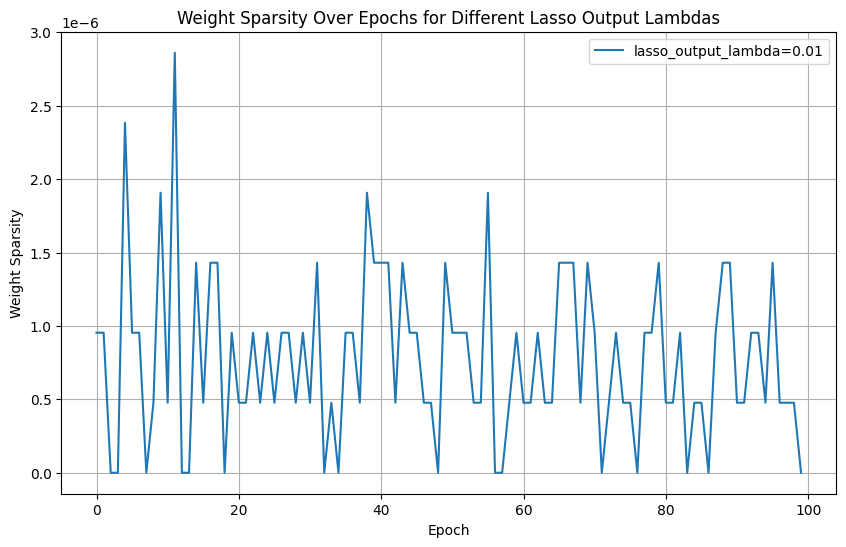

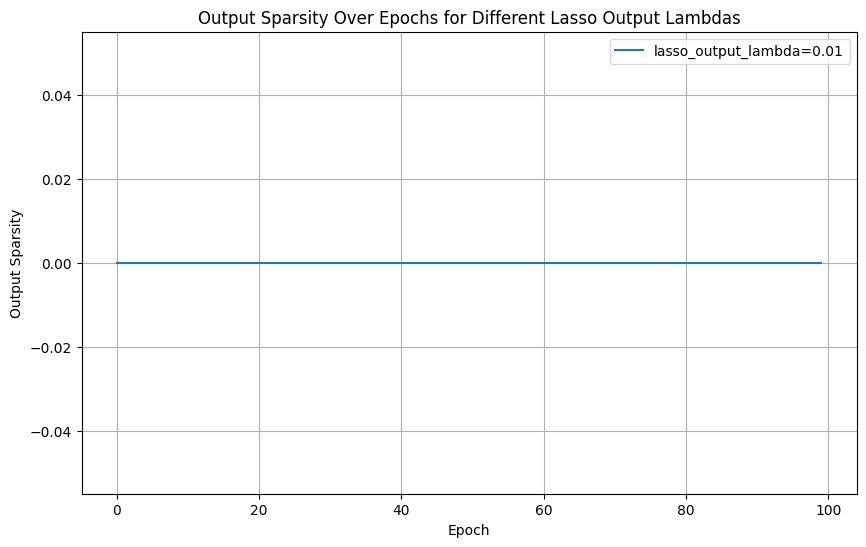

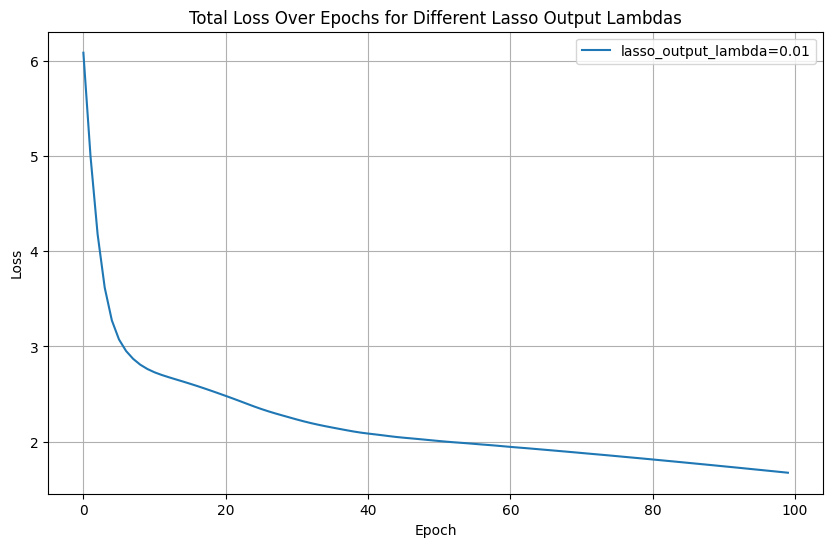

In [15]:
lasso_output_values = [0.01]

trained_models = compare_lasso_output_effects(lasso_output_values, num_epochs=100, learning_rate=0.001, lasso_output_type='row', zero_threshold=0.0)

Weight Sparsity: 0.0000 (1 of 2097152), Output Sparsity: 0.0000 (0 of 36864)


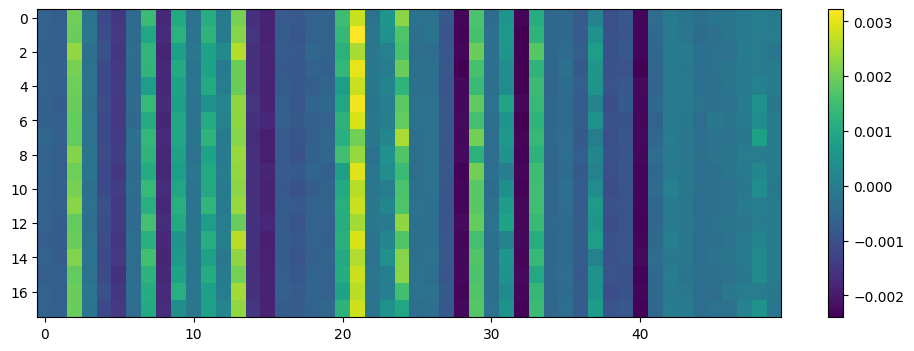

In [6]:
latent_bg_s, latent_t_s = validate(trained_models[0.01], zero_threshold=0.0)
show_latent_map(latent_t_s, img_idx = 0, show_weight = 50)

### comparison only the effect of lasso_output_lambda

In [7]:
# lasso_output_values = [0.0, 0.01, 0.1, 0.5]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='row', zero_threshold=0.0)

### Set lasso_output_type='elements'

In [8]:
# lasso_output_values = [0.0, 0.01, 0.1, 0.5]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='element', zero_threshold=0.0)

### combine this with zero_out, since the lasso does not make the output to be exactly zeros

In [9]:
# lasso_output_values = [0.0, 0.01, 0.1, 0.5]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='row', zero_threshold=0.01)

In [10]:
# lasso_output_values = [0.0, 0.01, 0.1, 0.5]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='row', zero_threshold=0.001)

In [11]:
# lasso_output_values = [0.0, 0.01, 0.001, 0.0001]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='row', zero_threshold=0.001)

In [12]:
# lasso_output_values = [0.0, 0.01, 0.001, 0.0001]
# compare_lasso_output_effects(lasso_output_values, num_epochs=1000, lasso_output_type='row', zero_threshold=0.0001)

In [13]:
4*18*512

36864